# 🔥 Physics-Informed Neural Network (PINN): 1D Heat Equation

This notebook demonstrates how to load a trained PINN model and use it to predict the temperature distribution of a 1D rod over time. 

### The Governing Equation
$$ \frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} $$

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from model import PINN
from heat_pinn import analytical_solution, compute_relative_l2_error

# Set plotting style
plt.style.use('default')

### 1. Load the Trained Model

In [2]:
checkpoint = torch.load('pinn_heat.pth', map_location=torch.device('cpu'))
cfg = checkpoint['config']

model = PINN(
    input_dim=2,
    hidden_dim=cfg['hidden_dim'],
    output_dim=1,
    num_hidden_layers=cfg.get('num_hidden_layers', 3)
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Model loaded successfully!\nParameters: {model.count_parameters():,}")

Model loaded successfully!
Parameters: 2,241


### 2. Generate Spatiotemporal Grid and Predict

In [3]:
nx, nt = 100, 100
x = np.linspace(-1, 1, nx)
t = np.linspace(0, 1, nt)
X, T = np.meshgrid(x, t)

x_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
t_flat = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    u_pred = model(x_flat, t_flat).numpy().reshape(nt, nx)
    u_exact = analytical_solution(x_flat, t_flat, alpha=cfg['alpha']).numpy().reshape(nt, nx)

error = np.abs(u_pred - u_exact)

### 3. Visualize Results

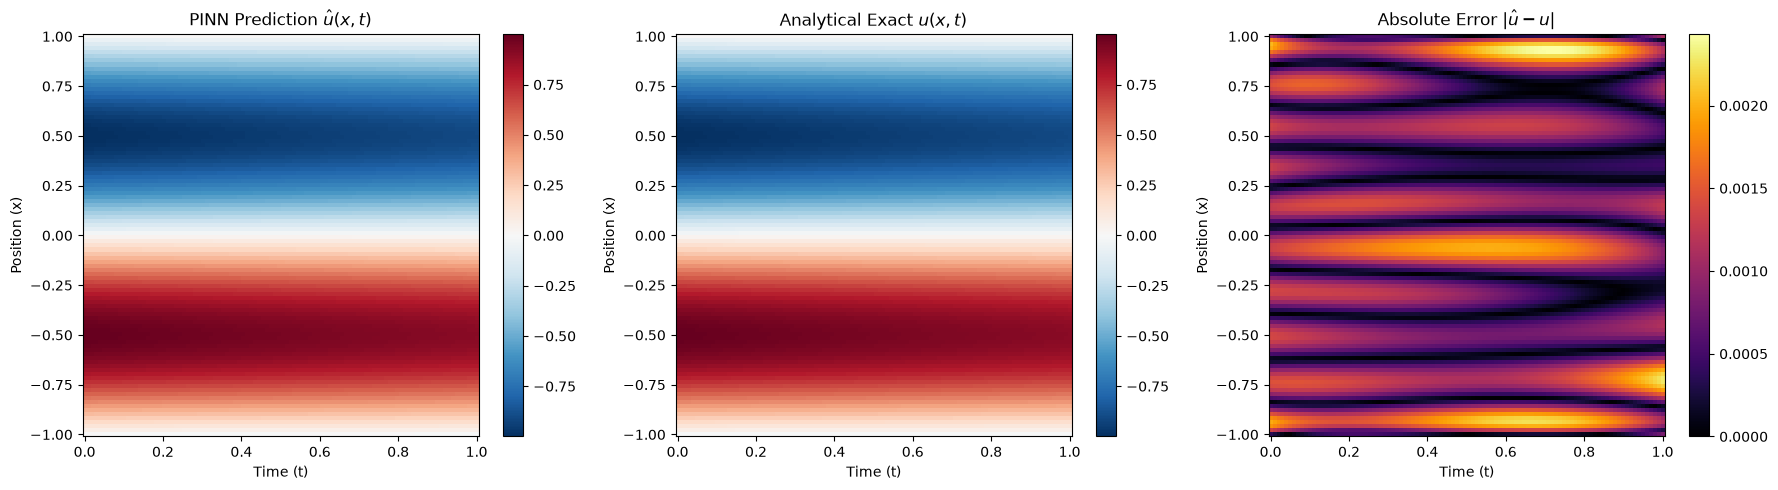

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmin, vmax = u_exact.min(), u_exact.max()

cf0 = axes[0].pcolormesh(T, X, u_pred, cmap='RdBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0].set_title('PINN Prediction $\\hat{u}(x,t)$')
fig.colorbar(cf0, ax=axes[0])

cf1 = axes[1].pcolormesh(T, X, u_exact, cmap='RdBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[1].set_title('Analytical Exact $u(x,t)$')
fig.colorbar(cf1, ax=axes[1])

cf2 = axes[2].pcolormesh(T, X, error, cmap='inferno', shading='auto', vmin=0, vmax=error.max())
axes[2].set_title('Absolute Error $|\\hat{u} - u|$')
fig.colorbar(cf2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('Time (t)')
    ax.set_ylabel('Position (x)')

plt.tight_layout()
plt.show()

### 4. Evaluate Global Metric

In [5]:
rel_l2 = compute_relative_l2_error(model, alpha=cfg['alpha'])
print(f"Global Relative L2 Error: {rel_l2 * 100:.4f}%")

Global Relative L2 Error: 0.1443%
